# Intro
This Jupyter Notebook is used to preprocess the [Kaggle’s BBC News RSS Dataset](https://www.kaggle.com/datasets/gpreda/bbc-news/data) before training a model. Please noted that we use this notebook with virtual environment.

## Import required libraries

In [1]:
import sys
import pandas as pd
import logging
from datetime import datetime
import os
from pathlib import Path

# Get the current directory (FYP/kaggle)
current_dir = Path.cwd()

# Go up one level to FYP
project_root = current_dir.parent.parent.parent
sys.path.append(str(project_root))

RAW_FILE_PATH = project_root / 'data' / 'raw' / 'kaggle' / 'bbc_news.csv'
SAVE_PATH = project_root / 'data' / 'processed' / 'kaggle'

# Understand the data

In [2]:
# Load the dataset into pandas
bbc_news_df = pd.read_csv(RAW_FILE_PATH)

# Print the number of rows and columns in the dataset
print(f"Number of rows: {bbc_news_df.shape[0]}")

# Display the first few rows of the dataset to understand its structure
bbc_news_df.head()


Number of rows: 42115


,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


## To analyze the distribution by date

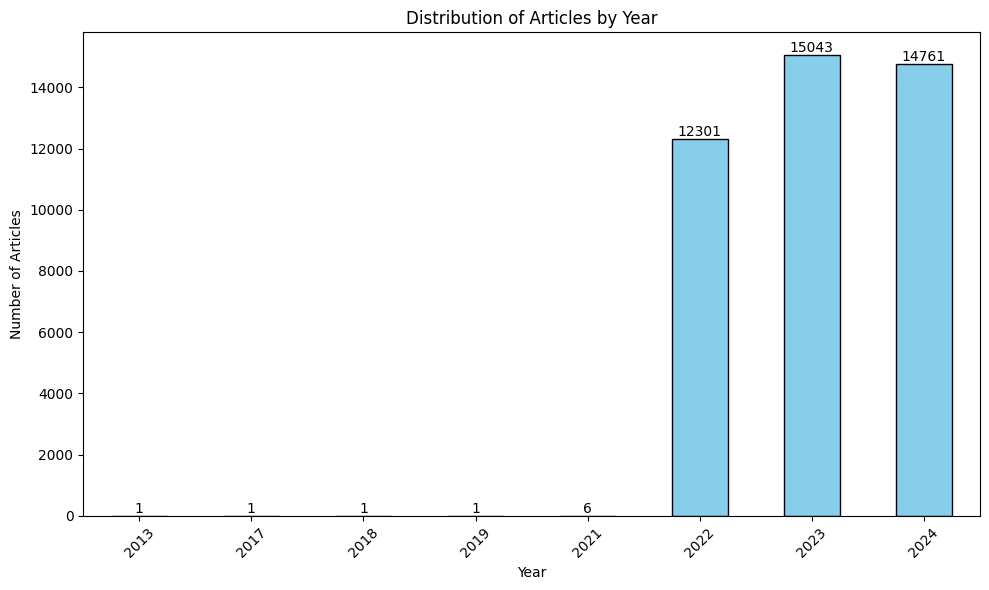

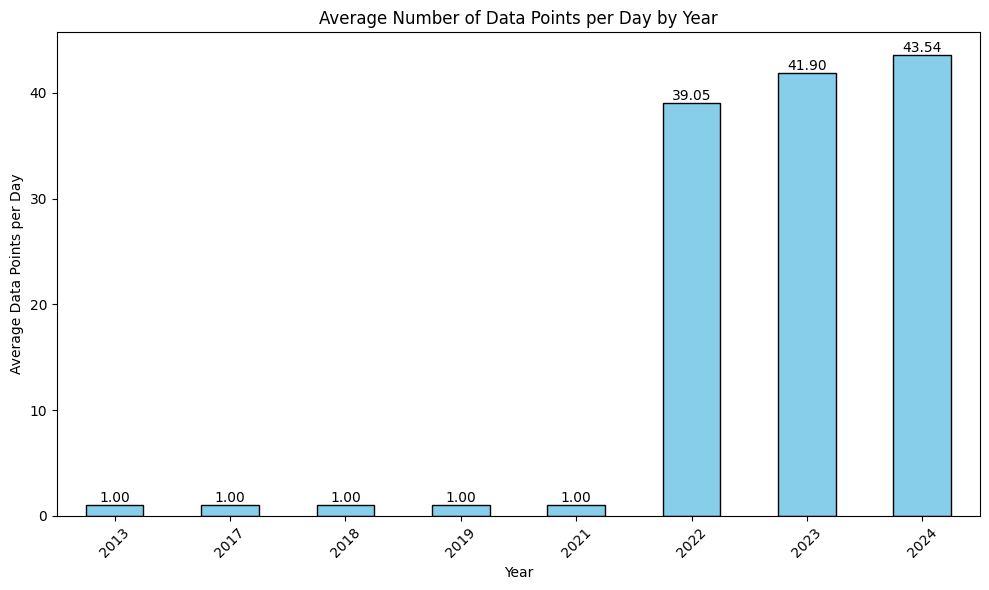

In [3]:
from src.utils.plot_df import plot_distribution_by_year, plot_description_length_distribution, plot_avg_per_day_by_year

plot_distribution_by_year(bbc_news_df, 'pubDate')
plot_avg_per_day_by_year(bbc_news_df, 'pubDate')

## The length of the description

Since FinBert’s maximum input sequence length is 512 tokens, we need to verify that each description does not exceed this limit to ensure our data can be processed by FinBert.

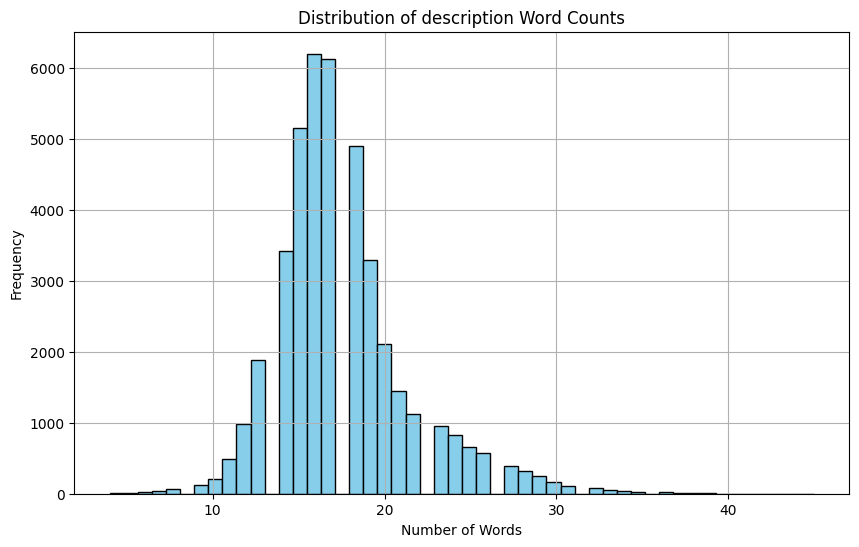

In [4]:
plot_description_length_distribution(bbc_news_df, 'description')

# Data cleaning

## Convert the date to utc format

In [5]:
from src.utils.data_format import clean_text_column, convert_datetime_column

# Datetime column
cleaned_df = convert_datetime_column(bbc_news_df, 'pubDate')

# Check the cleaned data
cleaned_df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,2022-03-07 08:01:56+00:00,https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,2022-03-06 22:49:58+00:00,https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',2022-03-07 00:14:42+00:00,https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,2022-03-07 00:05:40+00:00,https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,2022-03-07 08:15:53+00:00,https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


## Remove the Outlier Data
Since we found that a small number of data points fall outside the march 2022-2024 range, and for the sake of time relevance and consistency within the dataset, we have decided to remove these entries.

In [6]:
# Filter the dataset to keep data between March 2022 and December 2024
start_date = '2022-03-01'
end_date = '2024-12-31'

# Filter the rows based on the specified date range
cleaned_df = cleaned_df[(cleaned_df['pubDate'] >= start_date) & (cleaned_df['pubDate'] <= end_date)]

# Print the number of rows in the filtered dataset
print(f"Number of rows in the filtered dataset: {len(cleaned_df)}")

Number of rows in the filtered dataset: 42095


## Filter the dataset to keep only the 'news' category

In [7]:
import re

def extract_category(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """
    Extracts categories from the specified column that contains URLs and adds them as a new column.

    Args:
    - df (pd.DataFrame): The pandas dataframe containing the column.
    - column_name (str): The name of the column containing the URLs (guid).

    Returns:
    - pd.DataFrame: The original dataframe with a new column 'category' containing the extracted categories.
    """
    # Function to extract category from a URL
    def get_category(guid: str) -> str:
        match = re.search(r'https?://[^/]+/([^/]+)/', guid)
        if match:
            return match.group(1)
        print(f"Warning: No match found for guid: {guid}")
        return None
        
    # Apply the function to the column and create a new 'category' column
    df['category'] = df[column_name].apply(get_category)
    
    return df

In [8]:
cleaned_df = extract_category(cleaned_df, 'guid')

# Count unique categories
unique_categories = cleaned_df['category'].nunique()

# Display the unique categories and their count
print(f"Number of unique categories: {unique_categories}")
counts = cleaned_df['category'].value_counts()
print("Count by category:")
for cat, cnt in counts.items():
    print(f"{cat}: {cnt}")

Number of unique categories: 11
Count by category:
news: 33060
sport: 8392
sounds: 406
iplayer: 127
weather: 77
food: 12
articles: 8
newsround: 6
digihub: 3
programmes: 2
mediacentre: 1


/var/folders/s2/gqpw_6dd5n7b8c1hzy_q5s0w0000gn/T/ipykernel_16624/3594136202.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df[column_name].apply(get_category)


## Remove duplicated rows

In [9]:
from src.utils.plot_df import display_duplicate_rows_by_column

# Filter the dataset to keep only the 'news' category
cleaned_df = cleaned_df[cleaned_df['category'] == 'news'].reset_index(drop=True)

# Identify duplicate rows based on a single column 
display_duplicate_rows_by_column(cleaned_df, 'title')

# Remove some garbage rows
garbage_titles = [
    'BBC News app',
    'Download now'
]

# Sort the dataframe by 'pubDate' in descending order
cleaned_df = cleaned_df.sort_values(by='pubDate', ascending=True).reset_index(drop=True)
display(cleaned_df)

# Filter out the garbage and duplicates titles
cleaned_df = cleaned_df[~cleaned_df['title'].isin(garbage_titles)].reset_index(drop=True)
cleaned_df = cleaned_df.drop_duplicates(subset=['title'], keep='first').reset_index(drop=True)

# Check for duplicates in the 'description' and 'link' columns
# Their duplication is likely due to updated titles or descriptions. Using link to identify duplicates
display_duplicate_rows_by_column(cleaned_df, 'link')
cleaned_df = cleaned_df.drop_duplicates(subset=['link'], keep='first').reset_index(drop=True)

display(cleaned_df)


                                                   title  \
4      Ukraine conflict: Oil price soars to highest l...   
5      Ukraine war: PM to hold talks with world leade...   
18        Five ways the Ukraine war could push up prices   
44     Covid-19 in the UK: How many coronavirus cases...   
48     Ukraine conflict: Oil price soars to highest l...   
...                                                  ...   
32939  Tight three-way race in Irish general election...   
32940  Could police have handled Skye shooting differ...   
32957  'It's part of my DNA': Charli XCX and the figh...   
32967  Could police have handled Skye shooting differ...   
32969    Inside the £4m mansion Jurgen Klopp called home   

                        pubDate  \
4     2022-03-07 08:15:53+00:00   
5     2022-03-07 08:33:29+00:00   
18    2022-03-04 22:09:49+00:00   
44    2022-03-04 17:34:34+00:00   
48    2022-03-07 09:00:31+00:00   
...                         ...   
32939 2024-11-29 23:29:48+00:00   

,title,pubDate,guid,link,description,category
0,What are the latest rules for face coverings a...,2022-03-01 09:53:08+00:00,https://www.bbc.co.uk/news/health-51205344,https://www.bbc.co.uk/news/health-51205344?at_...,Rules around face coverings are easing across ...,news
1,Covid boosters: Who will get a fourth dose?,2022-03-02 12:11:20+00:00,https://www.bbc.co.uk/news/health-55045639,https://www.bbc.co.uk/news/health-55045639?at_...,Care workers in England won't need to be vacci...,news
2,Economic Crime Bill: What is it and will it fi...,2022-03-03 17:17:00+00:00,https://www.bbc.co.uk/news/uk-60579997,https://www.bbc.co.uk/news/uk-60579997?at_medi...,Will the Economic Crime Bill really tackle Put...,news
3,Ukraine war: Why Kherson and Mariupol are key ...,2022-03-04 12:54:25+00:00,https://www.bbc.co.uk/news/world-europe-60604876,https://www.bbc.co.uk/news/world-europe-606048...,There are both strategic and historical reason...,news
4,What are the UK's 'Living with Covid' plans?,2022-03-04 15:48:28+00:00,https://www.bbc.co.uk/news/explainers-52530518,https://www.bbc.co.uk/news/explainers-52530518...,All legal Covid restrictions in England have e...,news
...,...,...,...,...,...,...
33055,'Pickling a cucumber changed my life' says Tik...,2024-12-03 22:37:51+00:00,https://www.bbc.com/news/articles/c0lg82zlyp9o#0,https://www.bbc.com/news/articles/c0lg82zlyp9o,"A film parody actor, a pool cleaner and pickle...",news
33056,Scottish Budget presents huge challenges for SNP,2024-12-03 23:00:17+00:00,https://www.bbc.com/news/articles/ckg1m1j2grpo#9,https://www.bbc.com/news/articles/ckg1m1j2grpo,Finance Secretary Shona Robison is preparing t...,news
33057,Three rail firms to be renationalised next year,2024-12-04 00:02:37+00:00,https://www.bbc.com/news/articles/ceqlnrgjr79o#0,https://www.bbc.com/news/articles/ceqlnrgjr79o,The rail operators will be renationalised in M...,news
33058,School tells Muslim girls it’s ‘not safe’ for ...,2024-12-04 00:03:58+00:00,https://www.bbc.com/news/articles/cx2wk0k4597o#9,https://www.bbc.com/news/articles/cx2wk0k4597o,Three children have not been back to the Belfa...,news


                                                   title  \
1            Covid boosters: Who will get a fourth dose?   
4           What are the UK's 'Living with Covid' plans?   
5      Covid-19 in the UK: How many coronavirus cases...   
29     Ukraine maps: New agreed ceasefire breaks down...   
31     Ukraine invasion: Military couple marry on the...   
...                                                  ...   
30898           'I watched porn morning, noon and night'   
30941  British man killed on holiday in Turkey lift-s...   
30942  Holidaymaker killed in Turkey lift-shaft incident   
30956  Final seats to be filled in Irish general elec...   
30983  Fianna Fáil emerges as largest party in Irish ...   

                        pubDate  \
1     2022-03-02 12:11:20+00:00   
4     2022-03-04 15:48:28+00:00   
5     2022-03-04 17:34:34+00:00   
29    2022-03-06 14:10:23+00:00   
31    2022-03-06 19:00:39+00:00   
...                         ...   
30898 2024-11-29 21:18:13+00:00   

,title,pubDate,guid,link,description,category
0,What are the latest rules for face coverings a...,2022-03-01 09:53:08+00:00,https://www.bbc.co.uk/news/health-51205344,https://www.bbc.co.uk/news/health-51205344?at_...,Rules around face coverings are easing across ...,news
1,Covid boosters: Who will get a fourth dose?,2022-03-02 12:11:20+00:00,https://www.bbc.co.uk/news/health-55045639,https://www.bbc.co.uk/news/health-55045639?at_...,Care workers in England won't need to be vacci...,news
2,Economic Crime Bill: What is it and will it fi...,2022-03-03 17:17:00+00:00,https://www.bbc.co.uk/news/uk-60579997,https://www.bbc.co.uk/news/uk-60579997?at_medi...,Will the Economic Crime Bill really tackle Put...,news
3,Ukraine war: Why Kherson and Mariupol are key ...,2022-03-04 12:54:25+00:00,https://www.bbc.co.uk/news/world-europe-60604876,https://www.bbc.co.uk/news/world-europe-606048...,There are both strategic and historical reason...,news
4,What are the UK's 'Living with Covid' plans?,2022-03-04 15:48:28+00:00,https://www.bbc.co.uk/news/explainers-52530518,https://www.bbc.co.uk/news/explainers-52530518...,All legal Covid restrictions in England have e...,news
...,...,...,...,...,...,...
29358,'Pickling a cucumber changed my life' says Tik...,2024-12-03 22:37:51+00:00,https://www.bbc.com/news/articles/c0lg82zlyp9o#0,https://www.bbc.com/news/articles/c0lg82zlyp9o,"A film parody actor, a pool cleaner and pickle...",news
29359,Scottish Budget presents huge challenges for SNP,2024-12-03 23:00:17+00:00,https://www.bbc.com/news/articles/ckg1m1j2grpo#9,https://www.bbc.com/news/articles/ckg1m1j2grpo,Finance Secretary Shona Robison is preparing t...,news
29360,Three rail firms to be renationalised next year,2024-12-04 00:02:37+00:00,https://www.bbc.com/news/articles/ceqlnrgjr79o#0,https://www.bbc.com/news/articles/ceqlnrgjr79o,The rail operators will be renationalised in M...,news
29361,School tells Muslim girls it’s ‘not safe’ for ...,2024-12-04 00:03:58+00:00,https://www.bbc.com/news/articles/cx2wk0k4597o#9,https://www.bbc.com/news/articles/cx2wk0k4597o,Three children have not been back to the Belfa...,news


# Keep column

In [10]:
# First check what columns are actually available
print("Available columns:", cleaned_df.columns.tolist())

# Keep only the columns we want and rename them
columns_keep = ["title", "pubDate", "description"]  # Using the actual column names
cleaned_df = cleaned_df[columns_keep].rename(columns={
    "title": "headline",
    "pubDate": "date"
})

cleaned_df.head()

Available columns: ['title', 'pubDate', 'guid', 'link', 'description', 'category']


,headline,date,description
0,What are the latest rules for face coverings a...,2022-03-01 09:53:08+00:00,Rules around face coverings are easing across ...
1,Covid boosters: Who will get a fourth dose?,2022-03-02 12:11:20+00:00,Care workers in England won't need to be vacci...
2,Economic Crime Bill: What is it and will it fi...,2022-03-03 17:17:00+00:00,Will the Economic Crime Bill really tackle Put...
3,Ukraine war: Why Kherson and Mariupol are key ...,2022-03-04 12:54:25+00:00,There are both strategic and historical reason...
4,What are the UK's 'Living with Covid' plans?,2022-03-04 15:48:28+00:00,All legal Covid restrictions in England have e...


# Insert Sentiment Score

In [11]:
from src.utils.sentiment import add_sentiment_scores

# Add sentiment scores to the filtered DataFrame
sentiment_inserted_df = add_sentiment_scores(cleaned_df, 'description')

# Check the first few rows of the DataFrame with sentiment scores
display(sentiment_inserted_df.head())

# Save the filtered DataFrame with sentiment scores to a CSV file
sentiment_inserted_df.to_csv(str(SAVE_PATH)+"/sentiment_inserted.csv", index=False)

Device set to use mps:0
Processing Sentiment Scores: 100%|██████████| 29363/29363 [07:44<00:00, 63.26text/s]


,headline,date,description,sentiment_score_finbert
0,What are the latest rules for face coverings a...,2022-03-01 09:53:08+00:00,Rules around face coverings are easing across ...,-0.008794
1,Covid boosters: Who will get a fourth dose?,2022-03-02 12:11:20+00:00,Care workers in England won't need to be vacci...,0.014665
2,Economic Crime Bill: What is it and will it fi...,2022-03-03 17:17:00+00:00,Will the Economic Crime Bill really tackle Put...,-0.001412
3,Ukraine war: Why Kherson and Mariupol are key ...,2022-03-04 12:54:25+00:00,There are both strategic and historical reason...,0.038065
4,What are the UK's 'Living with Covid' plans?,2022-03-04 15:48:28+00:00,All legal Covid restrictions in England have e...,-0.175007
